# 2 · Model comparison

Which model family, and which features. Both answers turned out to be less interesting
than *how you measure* — so the protocol comes first.

## Two rules, both learned the hard way on this dataset

**Split by year, never randomly.** A fire burns for several days, and its cell-days are
near-duplicates. A random 5-fold split puts the same fire on both sides of the boundary,
so the model is partly scored on fires it memorised. The gap is measured below rather
than asserted.

**Fit the threshold on an inner year, never on the fold being scored.** Choosing the
best-F1 cutoff on the fold you then report is tuning on test. The inner split costs one
year of training data and buys an honest number.

A note on why this matters more than it sounds: threshold choice alone moved F1 from
0.282 to 0.50 on this data, without changing the model at all. Measurement decisions
dominated every modelling decision we tried.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd()))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from importlib import import_module
setup = import_module("00_setup")

from sklearn.base import clone
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import (average_precision_score, f1_score, precision_score,
                             recall_score, roc_auc_score)

d = setup.load_dataset()
BASE = setup.BASE_FEATURES
FULL = setup.MODEL_FEATURES
y, years = d["label"], d["year"]
print(f"{len(d):,} rows · positives {y.mean()*100:.1f}%")

121,869 rows · positives 24.9%


## The protocol

In [2]:
GRID = np.linspace(0.02, 0.98, 97)

def positive_proba(model, X):
    """P(fire). A fold whose training years contain no fires yields a single
    predict_proba column, so resolve via classes_ rather than [:, 1]."""
    p = model.predict_proba(X)
    classes = list(getattr(model, "classes_", [0, 1]))
    return p[:, classes.index(1)] if 1 in classes else np.zeros(len(X))

def best_threshold(y_true, proba, min_recall=None):
    best, best_f1 = 0.5, -1.0
    for t in GRID:
        yhat = (proba >= t).astype(int)
        if min_recall is not None and recall_score(y_true, yhat, zero_division=0) < min_recall:
            continue
        f = f1_score(y_true, yhat, zero_division=0)
        if f > best_f1:
            best, best_f1 = t, f
    return float(best)

def cross_validate(name, model, X, y, groups, folds=5, random_split=False):
    """Year-grouped CV with an inner year held out for threshold fitting.
    random_split=True exists only to demonstrate what leakage looks like."""
    splitter = (KFold(folds, shuffle=True, random_state=42).split(X)
                if random_split else GroupKFold(folds).split(X, y, groups))
    oof, rows = np.zeros(len(X)), []
    for tr, te in splitter:
        g = groups.iloc[tr]
        inner = np.sort(g.unique())[-1]
        fit = (g != inner).values
        cal = clone(model).fit(X.iloc[tr][fit], y.iloc[tr][fit])
        thr = best_threshold(y.iloc[tr][~fit], positive_proba(cal, X.iloc[tr][~fit]))
        final = clone(model).fit(X.iloc[tr], y.iloc[tr])
        p = positive_proba(final, X.iloc[te])
        oof[te] = p
        yhat = (p >= thr).astype(int)
        rows.append(dict(pr_auc=average_precision_score(y.iloc[te], p),
                         roc_auc=roc_auc_score(y.iloc[te], p),
                         precision=precision_score(y.iloc[te], yhat, zero_division=0),
                         recall=recall_score(y.iloc[te], yhat, zero_division=0),
                         f1=f1_score(y.iloc[te], yhat, zero_division=0),
                         threshold=thr))
    folds_df = pd.DataFrame(rows)
    print(f"  {name:<18} PR-AUC {folds_df.pr_auc.mean():.4f}±{folds_df.pr_auc.std():.3f}"
          f"   ROC {folds_df.roc_auc.mean():.4f}   P {folds_df.precision.mean():.3f}"
          f"   R {folds_df.recall.mean():.3f}   F1 {folds_df.f1.mean():.4f}")
    return folds_df, oof

## The cost of splitting randomly

Same model, same data, one line different.

In [3]:
import lightgbm as lgb
quick = lgb.LGBMClassifier(objective="binary", n_estimators=400, learning_rate=0.05,
                           num_leaves=63, min_child_samples=40, n_jobs=-1,
                           verbose=-1, random_state=42)
print("honest (grouped by year)")
grouped, _ = cross_validate("LightGBM", quick, d[BASE], y, years)
print("leaky (random split)")
leaky, _ = cross_validate("LightGBM", quick, d[BASE], y, years, random_split=True)

pr_gap = (leaky.pr_auc.mean() - grouped.pr_auc.mean()) / grouped.pr_auc.mean() * 100
print(f"\na random split overstates PR-AUC by {pr_gap:.0f}%")
print(f"  and reports a fold spread of ±{leaky.pr_auc.std():.3f} instead of "
      f"±{grouped.pr_auc.std():.3f}")
print("\nThe collapsed spread is the tell: random folds all look alike because")
print("each contains fragments of the same fires, so the estimate looks far")
print("more precise than it is. Year-grouped folds disagree because seasons")
print("genuinely differ - that disagreement is the real uncertainty.")

honest (grouped by year)


  LightGBM           PR-AUC 0.4594±0.076   ROC 0.7356   P 0.374   R 0.770   F1 0.5019
leaky (random split)


  LightGBM           PR-AUC 0.5567±0.004   ROC 0.7757   P 0.391   R 0.795   F1 0.5226

a random split overstates PR-AUC by 21%
  and reports a fold spread of ±0.004 instead of ±0.076

The collapsed spread is the tell: random folds all look alike because
each contains fragments of the same fires, so the estimate looks far
more precise than it is. Year-grouped folds disagree because seasons
genuinely differ - that disagreement is the real uncertainty.


## Feature sets

`days_since_last_fire` is the one feature that mattered. It is also the easiest to turn
into a leak — see the note in `firerisk.features.add_days_since_last_fire`. Counting fires
newer than the sampling buffer makes every small value exclusively positive, because
negatives were sampled at least 4 days from any fire. That version scored **0.688** and
was pure artefact.

In [4]:
for name, feats in [("weather only", BASE), ("+ fuel depletion", FULL)]:
    cross_validate(name, quick, d[feats], y, years)

  weather only       PR-AUC 0.4594±0.076   ROC 0.7356   P 0.374   R 0.770   F1 0.5019


  + fuel depletion   PR-AUC 0.5514±0.074   ROC 0.7767   P 0.465   R 0.653   F1 0.5364


## Model families

Boosted trees, bagged trees, and a neural network. The network needs scaling and a log on
the fuel sentinel; the trees need neither.

In [5]:
import xgboost as xgb
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

TUNED = dict(objective="binary", n_estimators=1275, learning_rate=0.0146, num_leaves=29,
             min_child_samples=197, subsample=0.5998, subsample_freq=1,
             colsample_bytree=0.7671, reg_alpha=0.0667, reg_lambda=3.2759,
             n_jobs=-1, verbose=-1, random_state=42)

families = {
    "LightGBM (tuned)": lgb.LGBMClassifier(**TUNED),
    "XGBoost": xgb.XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=7,
                                 subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                                 eval_metric="aucpr", tree_method="hist", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                           n_jobs=-1, random_state=42),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=300, min_samples_leaf=5,
                                       n_jobs=-1, random_state=42),
    "MLP (32)": Pipeline([("scale", StandardScaler()),
                          ("net", MLPClassifier(hidden_layer_sizes=(32,), batch_size=512,
                                                max_iter=100, early_stopping=True,
                                                n_iter_no_change=8, random_state=42))]),
}

X_tree = d[FULL]
X_net = X_tree.copy()
X_net["days_since_last_fire"] = np.log1p(X_net["days_since_last_fire"])

summary = {}
for name, model in families.items():
    X = X_net if name.startswith("MLP") else X_tree
    folds_df, _ = cross_validate(name, model, X, y, years)
    summary[name] = folds_df.mean()

pd.DataFrame(summary).T.sort_values("pr_auc", ascending=False).round(4)

  LightGBM (tuned)   PR-AUC 0.5594±0.074   ROC 0.7814   P 0.450   R 0.693   F1 0.5371


  XGBoost            PR-AUC 0.5494±0.073   ROC 0.7743   P 0.441   R 0.692   F1 0.5376


  RandomForest       PR-AUC 0.5463±0.077   ROC 0.7725   P 0.463   R 0.640   F1 0.5343


  ExtraTrees         PR-AUC 0.5130±0.089   ROC 0.7613   P 0.446   R 0.643   F1 0.5236


  MLP (32)           PR-AUC 0.5551±0.073   ROC 0.7772   P 0.451   R 0.674   F1 0.5377


,pr_auc,roc_auc,precision,recall,f1,threshold
LightGBM (tuned),0.5594,0.7814,0.4503,0.6929,0.5371,0.252
MLP (32),0.5551,0.7772,0.4510,0.6740,0.5377,0.256
XGBoost,0.5494,0.7743,0.4415,0.6917,0.5376,0.240
RandomForest,0.5463,0.7725,0.4628,0.6403,0.5343,0.286
ExtraTrees,0.5130,0.7613,0.4462,0.6428,0.5236,0.290


## The finding that matters

Boosted trees, bagged trees and a neural network land within about **0.01 PR-AUC** of each
other, against fold-to-fold noise of roughly **±0.07**. That is a tie, not a ranking.

When three unrelated inductive biases converge, the limit is the **information in the
features**, not the algorithm. Tuning confirmed it: a 40-configuration search chose heavy
regularisation — 29 leaves, minimum 197 samples per leaf — which is what a model does when
it is fighting noise rather than finding structure.

So further model work is not where the remaining gains are. Vegetation state (NDVI) is —
the model still has no idea how much fuel is present.

,gain_%
days_since_last_fire,26.0
dc,10.8
rh_mean,9.5
fwi,8.2
ffmc,5.3
vpd_max,4.8
bui,3.7
rh_min_7d_mean,3.4
precip_30d,3.0
precip_7d,3.0


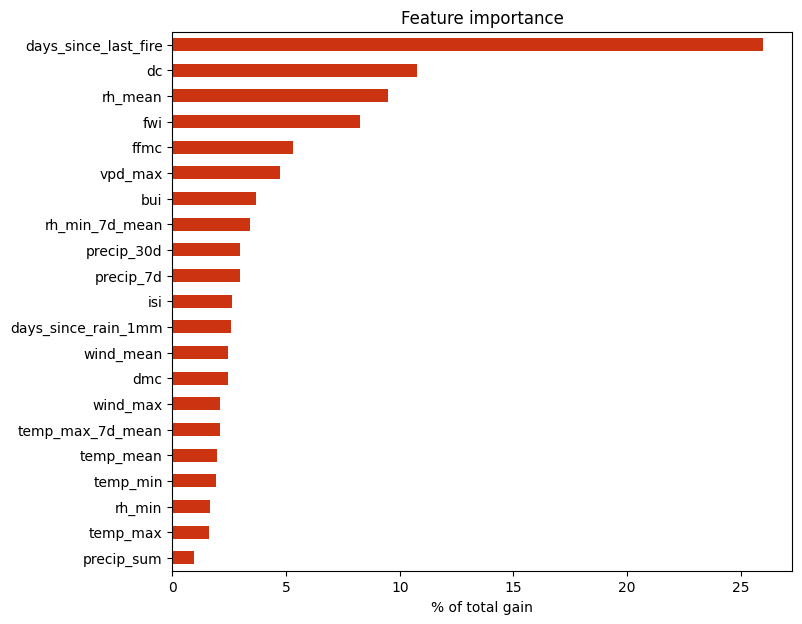

In [6]:
best = lgb.LGBMClassifier(**TUNED).fit(X_tree, y)
imp = pd.Series(best.booster_.feature_importance("gain"), index=FULL)
imp = (imp / imp.sum() * 100).sort_values()
ax = imp.plot(kind="barh", figsize=(8, 7), color="#cc3311")
ax.set_xlabel("% of total gain"); ax.set_title("Feature importance")
imp.sort_values(ascending=False).round(1).to_frame("gain_%").head(10)